In [33]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [7]:
mexico_gdp = pd.read_excel("pibt_cte_valor.xlsx")

In [21]:
values = pd.to_numeric(mexico_gdp.iloc[5, 2:])

# Create quarterly dates starting in 1993 Q1
quarters = pd.period_range(
    start="1993Q1",
    periods=len(values),
    freq="Q"
)

# Organize the data
gdp_clean = gdp_clean[
    gdp_clean["Quarter"] <= pd.Period("2025Q4", freq="Q")
].copy()


In [22]:
gdp_clean

,Quarter,Real_GDP
0,1993Q1,1.380463e+07
1,1993Q2,1.380375e+07
2,1993Q3,1.396407e+07
3,1993Q4,1.405191e+07
4,1994Q1,1.419417e+07
...,...,...
127,2024Q4,2.529083e+07
128,2025Q1,2.548670e+07
129,2025Q2,2.548058e+07
130,2025Q3,2.545387e+07


In [18]:
gdp_clean.describe()

,Real_GDP
count,1.320000e+02
mean,2.012116e+07
std,3.511100e+06
min,1.322474e+07
25%,1.774866e+07
50%,2.022648e+07
75%,2.329772e+07
max,2.569449e+07


In [24]:
Log_GDP= np.log(gdp_clean["Real_GDP"])

In [28]:
gdp_clean["Log_Real_GDP"] = np.log(gdp_clean["Real_GDP"])

In [30]:
gdp_clean["GDP_Growth"] = (
    100 * gdp_clean["Log_Real_GDP"].diff()
)

gdp_clean

,Quarter,Real_GDP,Log_Real_GDP,GDP_Growth
0,1993Q1,1.380463e+07,16.440515,NaN
1,1993Q2,1.380375e+07,16.440451,-0.006413
2,1993Q3,1.396407e+07,16.451998,1.154741
3,1993Q4,1.405191e+07,16.458269,0.627091
4,1994Q1,1.419417e+07,16.468342,1.007291
...,...,...,...,...
127,2024Q4,2.529083e+07,17.045952,-0.883594
128,2025Q1,2.548670e+07,17.053667,0.771485
129,2025Q2,2.548058e+07,17.053427,-0.024005
130,2025Q3,2.545387e+07,17.052378,-0.104861


In [31]:
gdp_clean.describe()

,Real_GDP,Log_Real_GDP,GDP_Growth
count,1.320000e+02,132.000000,131.000000
mean,2.012116e+07,16.801276,0.474254
std,3.511100e+06,0.182458,2.615576
min,1.322474e+07,16.397600,-20.964020
25%,1.774866e+07,16.691820,0.059965
50%,2.022648e+07,16.822503,0.669056
75%,2.329772e+07,16.963866,1.084922
max,2.569449e+07,17.061787,14.471375


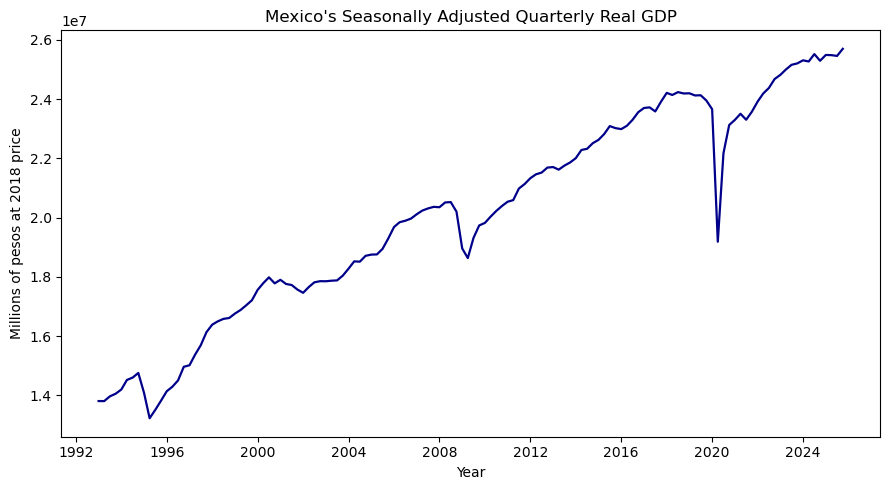

In [43]:
fig, ax = plt.subplots(figsize=(9, 5))
gdp_clean["Date"] = gdp_clean["Quarter"].dt.to_timestamp()
ax.plot(gdp_clean["Date"], gdp_clean["Real_GDP"], color="darkblue", linewidth=1.6)
ax.set_title("Mexico's Seasonally Adjusted Quarterly Real GDP")
ax.set_xlabel("Year")
ax.set_ylabel("Millions of pesos at 2018 price")
fig.tight_layout()
plt.show()